# Plant identification

First estimates the secondary path with an identification signal, then uses that estimate in a single-channel FxLMS controller.

Run the cells in order after installing the project from the repository root (see the [README](../../README.md)).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt
from helpers.room import room
from helpers.generateRirs import generateRirs

Simulation:

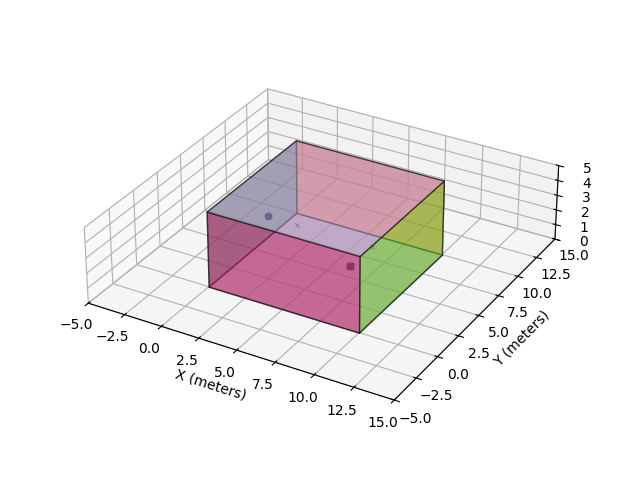

In [ ]:
fs = 48000
room = room(fs)


Obtain RIRs:

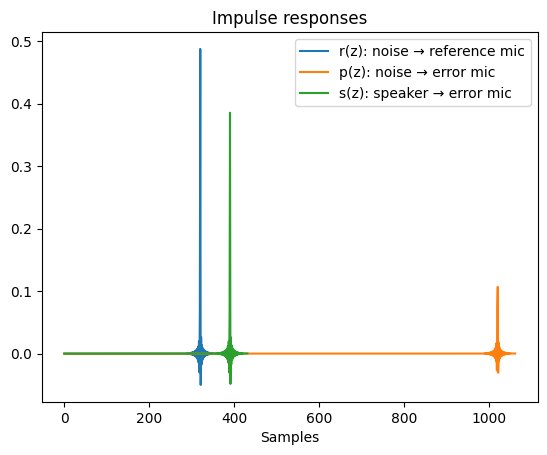

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [3]:
rir_r, rir_p, rir_s = generateRirs(fs, room)


System Identification

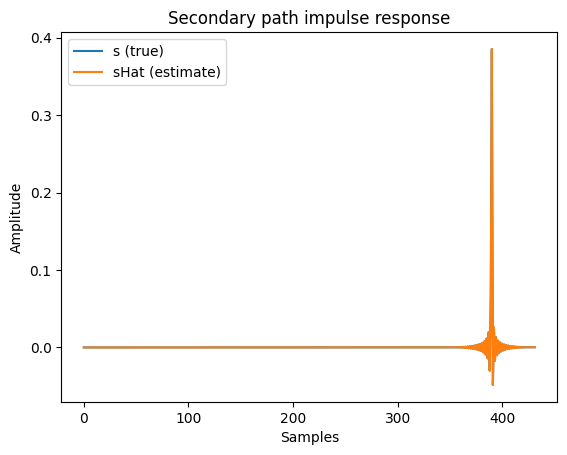

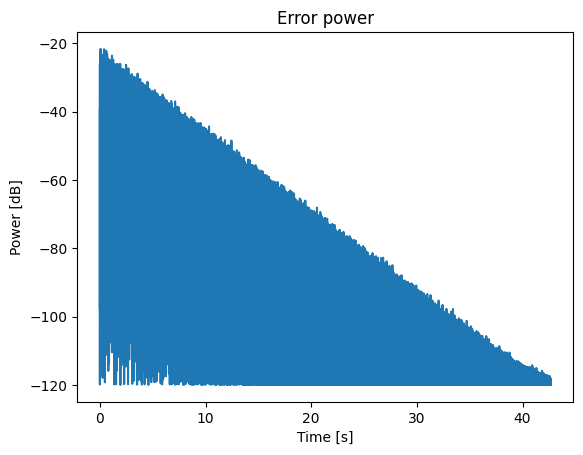

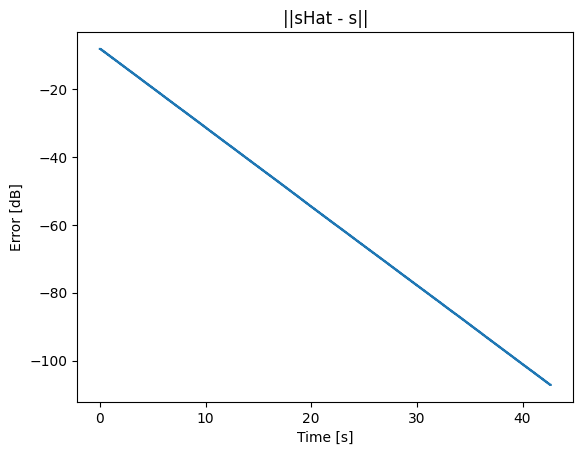

In [42]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)

# Identification noise initilization
identificationNoise = 0.05*np.random.randn(N)

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation - Simulates an estimation of the secondary path to initialize
sHat = np.zeros_like(s)
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatBufferPlantId = np.zeros(M_sHat - 1)
sHatOutputBlocksPlantId = []
muShat = 10

# History
ep_hist = np.zeros(N)
sHat_hist = np.zeros((N, M_sHat))

for k in range(nBlocks):
    # Identification noise inyection
    identificationNoiseBlock = identificationNoise[k*blocklength : (k+1)*blocklength]

    # Secondary path S(z)
    fIdNoiseBlockOutput, sBuffer = overlapSaveBlock(identificationNoiseBlock, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fIdNoiseBlockOutput)

    # Adapt secondary path model Shat(z)
    ypBlockOutput, sHatBufferPlantId = overlapSaveBlock(identificationNoiseBlock, sHatSpectrum, sHatBufferPlantId, M_sHat, N_sHat)
    sHatOutputBlocksPlantId.append(ypBlockOutput)
    
    ep = fIdNoiseBlockOutput - ypBlockOutput
    sHat = adapt(identificationNoiseBlock, ep, M_sHat, blocklength, sHat, muShat)
    sHatSpectrum = np.fft.rfft(sHat, N_sHat)

    # History
    ep_hist[k * blocklength:(k+1) * blocklength] = ep
    sHat_hist[k * blocklength:(k+1) * blocklength, :] = sHat

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(ep_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

s_error = np.linalg.norm(sHat_hist - s, axis=1)

plt.figure()
plt.plot(t, 20*np.log10(s_error + 1e-12))
plt.title('||sHat - s||')
plt.xlabel('Time [s]')
plt.ylabel('Error [dB]')
plt.show()


FxLMS with plant identification

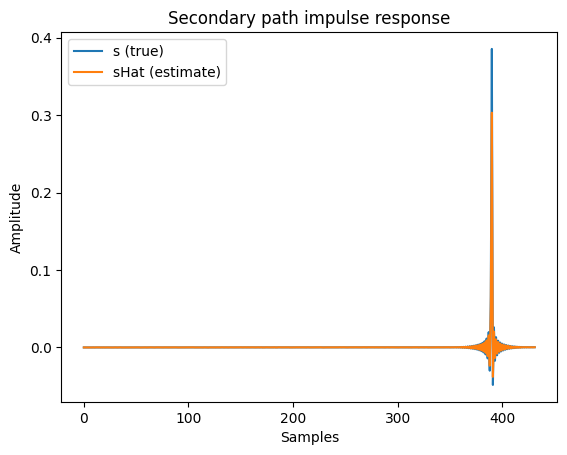

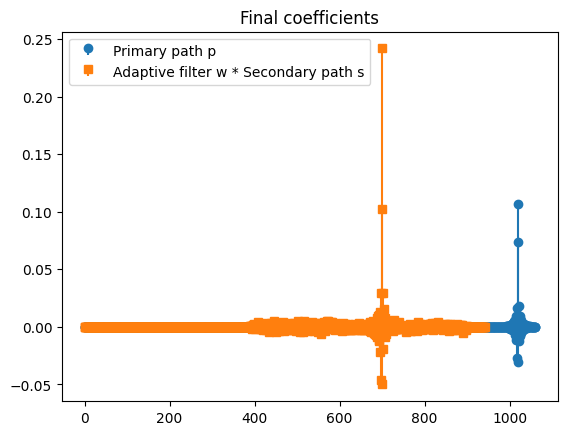

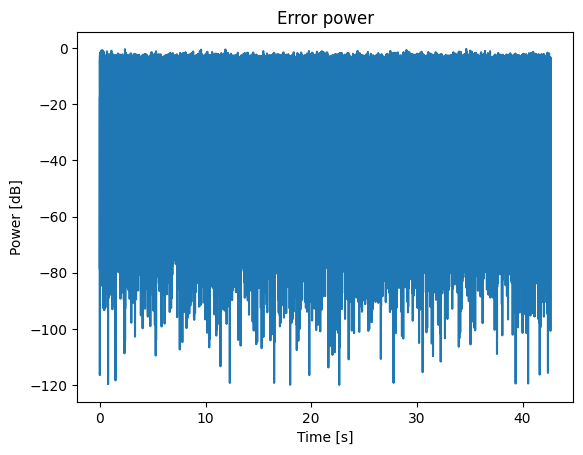

In [17]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 500
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Identification noise initilization
identificationNoise = 0.5*np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 5
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation  - Simulates an estimation of the secondary path to initialize
sHat = s #+ 0.05*np.random.randn(len(s))
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatBufferPlantId = np.zeros(M_sHat - 1)
sHatOutputBlocksPlantId = []
muShat = 0.001

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)
w_hist = np.zeros((N, M_w))
sHat_hist = np.zeros((N, M_sHat))

for k in range(nBlocks):
    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    
    # Identification noise inyection
    identificationNoiseBlock = identificationNoise[k*blocklength : (k+1)*blocklength]
    uBlock = yBlockOutput + identificationNoiseBlock
    
    # Secondary path S(z)
    fuBlockOutput, sBuffer = overlapSaveBlock(uBlock, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fuBlockOutput)

    # Error signal
    e = pBlockOutput - fuBlockOutput

    # Adapt secondary path model Shat(z)
    ypBlockOutput, sHatBufferPlantId = overlapSaveBlock(identificationNoiseBlock, sHatSpectrum, sHatBufferPlantId, M_sHat, N_sHat)
    sHatOutputBlocksPlantId.append(ypBlockOutput)
    
    ep = e - ypBlockOutput
    sHat = adapt(identificationNoiseBlock, ep, M_sHat, blocklength, sHat, muShat)
    sHatSpectrum = np.fft.rfft(sHat, N_sHat)

    # Filtered X
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    # LMS algorithm
    w = adapt(fxBlockOutput, e, M_w, blocklength, w, mu)

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e
    w_hist[k * blocklength:(k+1) * blocklength, :] = w
    sHat_hist[k * blocklength:(k+1) * blocklength, :] = sHat

plt.figure()
plt.plot(s, label='s (true)')
plt.plot(sHat, label='sHat (estimate)')
plt.legend()
plt.title('Secondary path impulse response')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

# plt.figure()
# for k in range(M_w):
#     plt.plot(t, w_hist[:, k])
# plt.title('Coefficient convergence')
# plt.xlabel('Time [s]')
# plt.ylabel('Value')
#plt.show()
